# Malware Detection with SGD
LSTM classifier trained with Stochastic Gradient Descent on opcode sequences.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Config

In [2]:
MAX_SEQ_LEN           = 200
VOCAB_SIZE            = 300
BATCH_SIZE            = 64
NUM_EPOCHS            = 80
LR                    = 0.01
MIN_SAMPLES_PER_CLASS = 25

## Data Pipeline
Loads from cache (`input/X.pt`, `input/y.pt`, `input/meta.json`) if it exists -> takes ~15 seconds.
On first run reads the zip, filters rare families, encodes sequences, and saves the cache - slow but only happens once.

In [3]:
import zipfile, json as _json, os
import numpy as np

CACHE_X    = 'input/X.pt'
CACHE_Y    = 'input/y.pt'
CACHE_META = 'input/meta.json'

if os.path.exists(CACHE_X) and os.path.exists(CACHE_Y) and os.path.exists(CACHE_META):
    # ---- fast path: load pre-processed tensors ----
    X = torch.load(CACHE_X)
    y = torch.load(CACHE_Y)
    with open(CACHE_META) as f:
        meta = _json.load(f)
    vocab_size  = meta['vocab_size']
    num_classes = meta['num_classes']
    label_map   = meta['label_map']
    print(f"Loaded from cache -” {X.shape[0]:,} samples, {num_classes} classes")

else:
    # ---- slow path: read zip, filter, encode, save cache ----
    print("Cache not found -” processing from zip (one-time)...")

    # 1. read zip
    rows, label_map = [], {}
    with zipfile.ZipFile('input/opcodes.zip') as z:
        entries = [e for e in z.infolist()
                   if not e.filename.endswith('/') and e.file_size > 0
                   and len(e.filename.split('/')) >= 3]
        print(f"  Reading {len(entries):,} files from zip...")
        for i, entry in enumerate(entries):
            parts  = entry.filename.split('/')
            family = parts[1]
            if family not in label_map:
                label_map[family] = len(label_map)
            raw = z.read(entry.filename).decode('utf-8', errors='replace')
            rows.append({'opcodes': ' '.join(raw.split()), 'label': label_map[family]})
            if (i + 1) % 25000 == 0:
                print(f"    {i+1:,} / {len(entries):,} files read...")
    df = pd.DataFrame(rows)
    print(f"  Read {len(df):,} samples, {df['label'].nunique()} families")

    # 2. filter rare families
    counts        = df['label'].value_counts()
    keep          = counts[counts >= MIN_SAMPLES_PER_CLASS].index
    df            = df[df['label'].isin(keep)].copy()
    unique_labels = sorted(df['label'].unique())
    remap         = {old: new for new, old in enumerate(unique_labels)}
    df['label']   = df['label'].map(remap)
    label_map     = {fam: remap[idx] for fam, idx in label_map.items() if idx in remap}
    print(f"  After filtering: {len(df):,} samples, {df['label'].nunique()} classes")

    # 3. build vocab
    token_counts = Counter()
    for seq in df['opcodes']:
        token_counts.update(seq.split())
    most_common = [tok for tok, _ in token_counts.most_common(VOCAB_SIZE - 2)]
    token2idx   = {tok: i + 2 for i, tok in enumerate(most_common)}
    vocab_size  = len(token2idx) + 2
    print(f"  Vocab built -” {vocab_size} tokens")

    # 4. encode into pre-allocated numpy array (avoids huge list-of-lists - much faster)
    print(f"  Encoding {len(df):,} sequences...")
    opcodes_list = df['opcodes'].tolist()
    n    = len(opcodes_list)
    X_np = np.zeros((n, MAX_SEQ_LEN), dtype=np.int32)  # 0 = PAD
    for i, seq in enumerate(opcodes_list):
        tokens = seq.split()[:MAX_SEQ_LEN]
        for j, t in enumerate(tokens):
            X_np[i, j] = token2idx.get(t, 1)           # 1 = UNK
        if (i + 1) % 25000 == 0:
            print(f"    {i+1:,} / {n:,} encoded...")
    X           = torch.from_numpy(X_np).long()
    y           = torch.tensor(df['label'].values, dtype=torch.long)
    num_classes = int(y.unique().size(0))
    print(f"  Encoded - shape: {X.shape}")

    # 5. save cache
    torch.save(X, CACHE_X)
    torch.save(y, CACHE_Y)
    with open(CACHE_META, 'w') as f:
        _json.dump({'vocab_size': vocab_size, 'num_classes': num_classes,
                    'label_map': label_map}, f)
    print("  Cache saved - future runs will load in ~15 seconds")

Loaded from cache -” 206,738 samples, 309 classes


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val,  y_train, y_val  = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

val_loader  = DataLoader(TensorDataset(X_val,  y_val),  batch_size=BATCH_SIZE)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

# SGD iterates over a shuffled DataLoader (shuffle handled by PyTorch internally)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)

Train: 148851  Val: 16539  Test: 41348


## Model
Embedding â†’ LSTM â†’ Linear.

In [5]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_out):  # (batch, seq, hidden*2)
        scores  = self.attn(lstm_out)              # (batch, seq, 1)
        weights = torch.softmax(scores, dim=1)     # (batch, seq, 1)
        return (lstm_out * weights).sum(dim=1)     # (batch, hidden*2)


class MalwareLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 128, padding_idx=0)
        self.lstm      = nn.LSTM(128, 256, num_layers=2, batch_first=True,
                                 dropout=0.4, bidirectional=True)
        self.attention = Attention(256)
        self.dropout   = nn.Dropout(0.4)
        self.fc        = nn.Linear(256 * 2, num_classes)

    def forward(self, x):
        x        = self.embedding(x)               # (batch, seq, 128)
        out, _   = self.lstm(x)                    # (batch, seq, 512)
        context  = self.attention(out)             # (batch, 512)
        return self.fc(self.dropout(context))


model = MalwareLSTM().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")


MalwareLSTM(
  (embedding): Embedding(300, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (attention): Attention(
    (attn): Linear(in_features=512, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=512, out_features=309, bias=True)
)
Trainable parameters: 2,564,918


## SGD Optimizer and Loss

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=1e-4)
# Restarts every T_0 epochs - helps escape local minima
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20, eta_min=1e-4)


## Training Loop

In [7]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

for epoch in range(1, NUM_EPOCHS + 1):
    # ---- train ----
    model.train()
    total_loss, correct, total = 0, 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct    += (out.argmax(1) == yb).sum().item()
        total      += yb.size(0)

    train_loss = total_loss / total
    train_acc  = correct / total
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)

    # ---- validate ----
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            val_loss    += criterion(out, yb).item() * xb.size(0)
            val_correct += (out.argmax(1) == yb).sum().item()
            val_total   += yb.size(0)

    v_loss = val_loss / val_total
    v_acc  = val_correct / val_total
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:>2} | "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.2%} | "
              f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.2%} | "
              f"LR: {lr_now:.5f}")


Epoch  1 | Train Loss: 3.3457  Acc: 38.04% | Val Loss: 2.5959  Acc: 46.36% | LR: 0.00994
Epoch  5 | Train Loss: 1.5857  Acc: 63.11% | Val Loss: 1.4579  Acc: 66.22% | LR: 0.00855
Epoch 10 | Train Loss: 1.2100  Acc: 70.28% | Val Loss: 1.1669  Acc: 71.70% | LR: 0.00505
Epoch 15 | Train Loss: 0.9990  Acc: 74.49% | Val Loss: 1.0210  Acc: 74.90% | LR: 0.00155
Epoch 20 | Train Loss: 0.8971  Acc: 76.86% | Val Loss: 0.9590  Acc: 76.35% | LR: 0.01000
Epoch 25 | Train Loss: 1.0188  Acc: 73.70% | Val Loss: 1.0317  Acc: 74.53% | LR: 0.00855
Epoch 30 | Train Loss: 0.8396  Acc: 77.61% | Val Loss: 0.9083  Acc: 77.27% | LR: 0.00505
Epoch 35 | Train Loss: 0.6806  Acc: 81.28% | Val Loss: 0.8090  Acc: 79.50% | LR: 0.00155
Epoch 40 | Train Loss: 0.6048  Acc: 83.24% | Val Loss: 0.7691  Acc: 80.63% | LR: 0.01000
Epoch 45 | Train Loss: 0.7887  Acc: 78.50% | Val Loss: 0.8928  Acc: 77.42% | LR: 0.00855
Epoch 50 | Train Loss: 0.6413  Acc: 82.07% | Val Loss: 0.7988  Acc: 79.78% | LR: 0.00505
Epoch 55 | Train Loss

## Training Curves

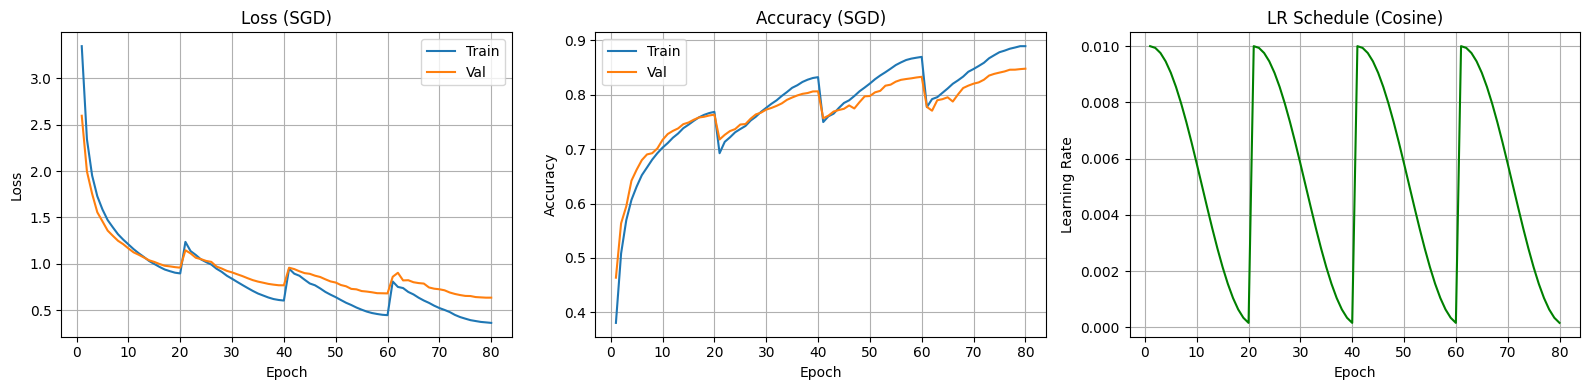

In [8]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

ax1.plot(epochs, history['train_loss'], label='Train')
ax1.plot(epochs, history['val_loss'],   label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss (SGD)'); ax1.legend(); ax1.grid(True)

ax2.plot(epochs, history['train_acc'], label='Train')
ax2.plot(epochs, history['val_acc'],   label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy (SGD)'); ax2.legend(); ax2.grid(True)

ax3.plot(epochs, history['lr'], color='green')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Learning Rate')
ax3.set_title('LR Schedule (Cosine)'); ax3.grid(True)

plt.tight_layout()
plt.savefig('output/sgd_curves.png', dpi=150)
plt.show()


## Test Evaluation

In [9]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.60      0.52      0.56        23
           1       0.67      0.46      0.55        13
           2       0.84      0.74      0.79       227
           3       0.76      0.36      0.49        36
           4       0.00      0.00      0.00        44
           5       0.00      0.00      0.00        70
           6       0.43      1.00      0.60        91
           7       0.61      0.86      0.71       512
           8       0.84      0.83      0.83       122
           9       1.00      0.50      0.67        12
          10       0.96      0.96      0.96        25
          11       0.81      0.82      0.82       187
          12       0.81      0.62      0.70        87
          13       0.65      0.31      0.42        35
          14       0.73      0.37      0.49        52
          15       0.68      0.54      0.60        63
          16       0.99      0.99      0.99       601
          17       1.00    

c:\Users\harun\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\harun\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\harun\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

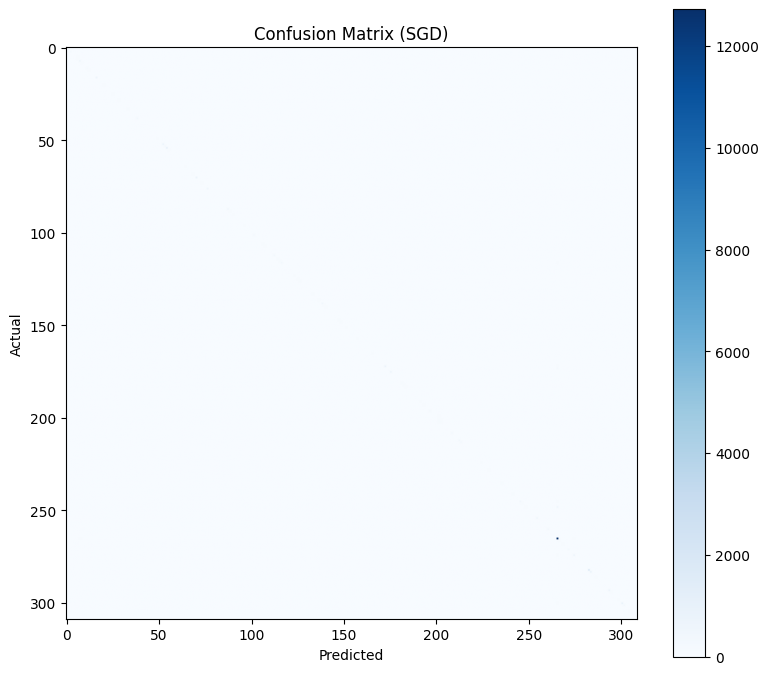

In [10]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (SGD)')
plt.tight_layout()
plt.savefig('output/sgd_confusion.png', dpi=150)
plt.show()

## Save

In [11]:
import json, os

os.makedirs("output", exist_ok=True)

with open('output/sgd_history.json', 'w') as f:
    json.dump(history, f)

torch.save(model.state_dict(), 'output/sgd_model.pt')

test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"Test accuracy: {test_acc:.2%}")
print('Saved to output/: sgd_history.json, sgd_model.pt, sgd_curves.png, sgd_confusion.png')

Test accuracy: 84.47%
Saved to output/: sgd_history.json, sgd_model.pt, sgd_curves.png, sgd_confusion.png
